# This notebook shows how to compute the $\mathbb{Z}_2$ invariant from parity eigenvalues alone, with no Brillouin-zone mesh
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.parsers import symmetry

### Parity eigenvalues and the Fu-Kane indicator
If the crystal has an inversion centre, inversion maps $\mathbf{k}\to-\mathbf{k}$, so at a time-reversal-invariant momentum (TRIM, every fractional component 0 or $\tfrac12$) the states are eigenstates of $\hat I$ with eigenvalues $\xi=\pm1$. Then
$$ \delta_i=\prod_{m=1}^{N}\xi_{2m}(\Gamma_i), \qquad (-1)^{\nu}=\prod_i \delta_i $$
with the product in $\delta_i$ over one member of each Kramers pair (Fu & Kane, PRB 76, 045302 (2007)). Four k-points in 2D, eight in 3D — no mesh, and exact rather than convergent.

In [2]:
# Bohr, monolayer graphene. Intrinsic carbon SOC is ~microeV, far too small to
# resolve, so soc_scale enhances it -- this changes the gap size, not the phase
A = 2.46 / 0.529177210903
GRAPHENE_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, 20.0)]
GRAPHENE_SPECIES = {"C": [(0.0, 0.0, 0.5), (1 / 3, 2 / 3, 0.5)]}

graphene = Structure(GRAPHENE_AVEC, GRAPHENE_SPECIES).get_calculation(
    "_scratch/graphene_parity", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    spinorb=True, soc_scale={"C": 3000.0},
)
graphene.get_energy()

-75.821473752577

### Occupied-band count
From `EIGVAL.OUT`'s own occupation numbers (`spinorb` forces `nspinor=2`, so Elk's `occmax` is 1.0 per state here, not 2.0).

In [3]:
first_block = (graphene.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)
ist1

6

### The invariant, from four k-points
Kane & Mele (PRL 95, 146802 (2005)) predict graphene with intrinsic spin-orbit coupling is a quantum spin Hall insulator, $\nu=1$.

In [4]:
result = graphene.get_fu_kane_invariant(1, ist1, dimension=2)
result["nu"], result["deltas"]

(1,
 {(0.0, 0.0, 0.0): -1,
  (0.0, 0.5, 0.0): -1,
  (0.5, 0.0, 0.0): 1,
  (0.5, 0.5, 0.0): -1})

### The parity spectrum at each TRIM
$\delta_i=(-1)^{N_-/2}$ with $N_-$ the number of $-1$ eigenvalues: Kramers partners share a parity eigenvalue, so the product over *all* occupied states would be identically $+1$ and carry no information. One TRIM has an odd number of occupied Kramers pairs with odd parity, which is what makes $\nu=1$.

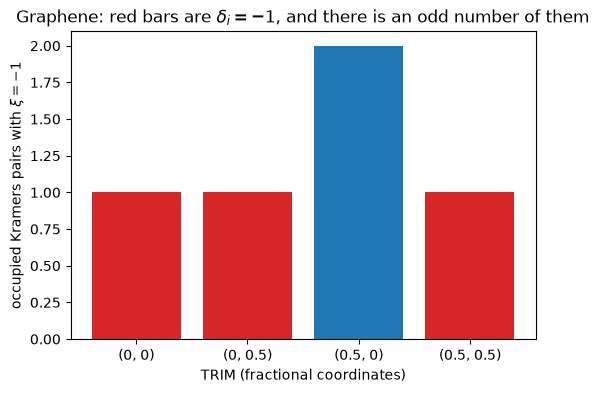

In [5]:
labels, counts, colors = [], [], []
with graphene.eigenstate_session() as session:
    for k in symmetry.TRIM_2D:
        xi = symmetry.parity_eigenvalues(session.parity(k, 1, ist1).pmat)
        counts.append(int(np.sum(xi < 0)) // 2)  # odd-parity Kramers pairs
        labels.append(f"({k[0]:g}, {k[1]:g})")
        colors.append("C3" if result["deltas"][k] < 0 else "C0")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts, color=colors)
ax.set_xlabel("TRIM (fractional coordinates)")
ax.set_ylabel("occupied Kramers pairs with $\\xi=-1$")
ax.set_title(r"Graphene: red bars are $\delta_i=-1$, and there is an odd number of them")
plt.show()